# CryptoBot — Étape 3 : modélisation

**Objectif** : entraîner des modèles qui décident d'acheter, de vendre ou d'attendre, les comparer, les optimiser, puis mesurer ce qu'ils auraient rapporté.

Ce notebook rejoue toute la démarche sur l'extrait figé des données, du chargement jusqu'à l'export des modèles :

1. Vérification de l'extrait figé
2. Exploration des données
3. Étiquetage par trois barrières (stop loss / take profit)
4. Construction des variables avec la librairie `ta`
5. Comparaison des modèles
6. Métriques : accuracy, bon sens directionnel, R²
7. Optimisation avec GridSearchCV
8. Modèles finaux et backtest
9. Suivi MLflow
10. Export `.joblib`

**Prérequis** : l'extrait figé dans `data/extract/` (fichier `extrait_fige_cryptobot.zip` décompressé). Durée d'exécution complète : une dizaine de minutes.

In [1]:
import os, sys, json, warnings
from pathlib import Path
from datetime import datetime, timezone

os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
warnings.filterwarnings("ignore")

# Le notebook vit dans notebooks/ : on remonte a la racine du projet pour
# reutiliser exactement le code de collecte et de preparation.
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             r2_score, mean_squared_error, mean_absolute_error)

from src import config
from src.preprocessing import INTERVAL_SECONDS

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# --- Palette des graphiques --------------------------------------------------
# Trois profils = les trois premiers emplacements de la palette categorielle de
# reference, valides deux a deux pour les principaux daltonismes.
COULEURS = {"scalping": "#2a78d6", "day_trading": "#eb6834", "swing": "#1baf7a"}
NOMS = {"scalping": "Scalping", "day_trading": "Day trading", "swing": "Swing"}
ENCRE, ENCRE_2, DISCRET = "#0b0b0b", "#52514e", "#898781"
GRILLE, AXE, FOND = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLEU, ROUGE, GRIS = "#2a78d6", "#e34948", "#c3c2b7"   # achat / vente / attente

mpl.rcParams.update({
    "figure.facecolor": FOND, "axes.facecolor": FOND, "savefig.facecolor": FOND,
    "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.edgecolor": AXE, "axes.labelcolor": ENCRE_2, "axes.titlecolor": ENCRE,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.6,
    "xtick.color": AXE, "ytick.color": AXE,
    "xtick.labelcolor": ENCRE_2, "ytick.labelcolor": ENCRE_2,
    "lines.linewidth": 1.6, "figure.dpi": 110, "legend.frameon": False,
})

def pipeline_de(modele):
    """Imputation et normalisation DANS le pipeline : elles sont ajustees sur
    l'entrainement seul, sans laisser fuiter les statistiques du test."""
    return Pipeline([("imputation", SimpleImputer(strategy="median")),
                     ("normalisation", StandardScaler()),
                     ("modele", modele)])

def milliers(v, _=None):
    return f"{v:,.0f}".replace(",", " ")

print("Racine du projet :", RACINE)

Racine du projet : C:\Training\jul26_bde_crypto


## 1. Vérification de l'extrait figé

Tous les modèles sont entraînés sur le même extrait, coupé à une date fixe. Chaque fichier a une empreinte SHA-256 : si elle ne correspond plus, les données ont changé et les résultats ne sont plus comparables.

In [2]:
from scripts.make_extract import empreinte, MANIFEST, EXTRACT_DIR

manifeste = json.loads(MANIFEST.read_text(encoding="utf-8"))
verification = pd.DataFrame([
    {"profil": profil,
     "lignes": meta["lignes"],
     "empreinte": meta["sha256"][:16] + "…",
     "intact": "oui" if empreinte(EXTRACT_DIR / meta["fichier"]) == meta["sha256"] else "NON"}
    for profil, meta in manifeste["profils"].items()
])
print("Date de coupure :", manifeste["cutoff"][:10])
verification

Date de coupure : 2026-08-24


,profil,lignes,empreinte,intact
0,scalping,1590455,0fadfbd6e67cffda…,oui
1,day_trading,456415,e7313c3291b11fba…,oui
2,swing,77975,40908d49cd79f00e…,oui


## 2. Exploration des données

Trois profils de trading, chacun avec ses pas de temps : le scalping regarde la minute, le day trading l'heure, le swing le jour et la semaine.

In [3]:
donnees = {p: pd.read_parquet(EXTRACT_DIR / f"{p}.parquet") for p in config.TRADING_PROFILES}

def incoherences(df):
    """Bougies dont le plus haut n'est pas le plus haut, ou le plus bas pas le plus bas."""
    haut = df["high"] < df[["open", "close", "low"]].max(axis=1)
    bas = df["low"] > df[["open", "close", "high"]].min(axis=1)
    return int((haut | bas).sum())

pd.DataFrame([{
    "profil": p,
    "lignes": len(df),
    "paires": df["symbol"].nunique(),
    "pas de temps": ", ".join(sorted(df["interval"].unique(), key=INTERVAL_SECONDS.get)),
    "début": df["open_time"].min().date(),
    "fin": df["open_time"].max().date(),
    "valeurs nulles": int(df.isna().sum().sum()),
    "doublons": int(df.duplicated(["symbol", "interval", "open_time"]).sum()),
    "incohérences de prix": incoherences(df),
} for p, df in donnees.items()])

,profil,lignes,paires,pas de temps,début,fin,valeurs nulles,doublons,incohérences de prix
0,scalping,1590455,5,"1m, 5m, 15m",2026-03-02,2026-08-24,0,0,0
1,day_trading,456415,5,"15m, 1h, 4h",2024-08-29,2026-08-24,0,0,0
2,swing,77975,5,"4h, 1d, 1w",2020-09-01,2026-08-24,0,0,0


Aucune valeur nulle, aucun doublon, aucune incohérence de prix : les contrôles faits à la collecte (étape 1) tiennent toujours.

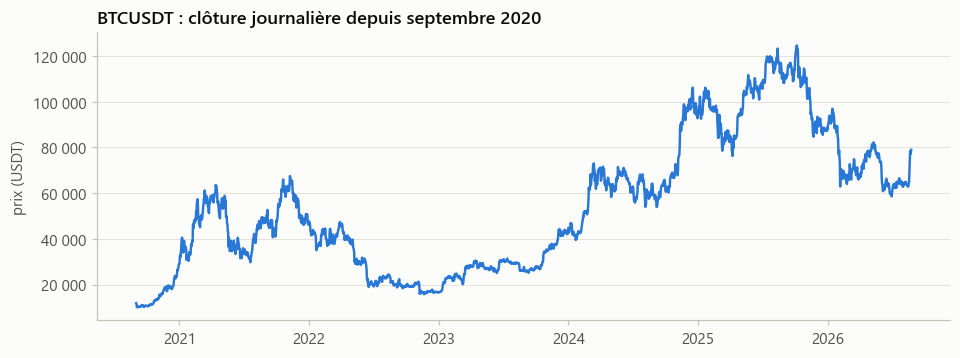

In [4]:
btc_jour = donnees["swing"].query("symbol == 'BTCUSDT' and interval == '1d'").sort_values("open_time")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(btc_jour["open_time"], btc_jour["close"], color=BLEU)
ax.set_title("BTCUSDT : clôture journalière depuis septembre 2020")
ax.set_ylabel("prix (USDT)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(milliers))
ax.grid(axis="x", visible=False)
plt.show()

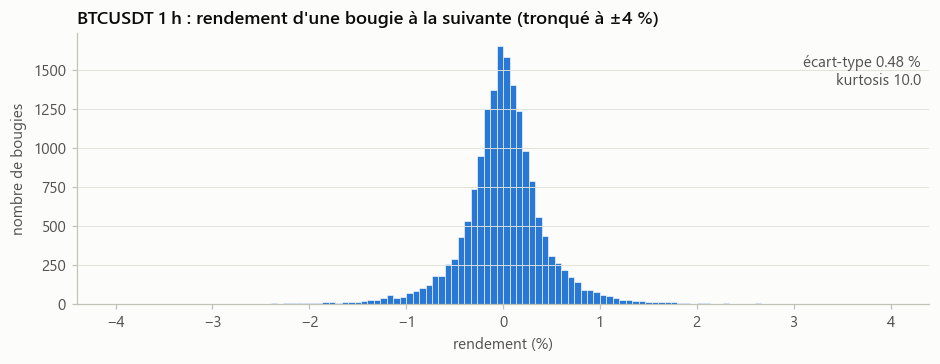

Mouvements de plus de 3 écarts-types : 1.91 % des bougies (une loi normale en donnerait 0,27 %)


In [5]:
btc_heure = (donnees["day_trading"]
             .query("symbol == 'BTCUSDT' and interval == '1h'")
             .sort_values("open_time").copy())
rendements = btc_heure["close"].pct_change().dropna() * 100
kurtosis = stats.kurtosis(rendements)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(rendements.clip(-4, 4), bins=120, color=BLEU, edgecolor=FOND, linewidth=0.4)
ax.set_title("BTCUSDT 1 h : rendement d'une bougie à la suivante (tronqué à ±4 %)")
ax.set_xlabel("rendement (%)")
ax.set_ylabel("nombre de bougies")
ax.grid(axis="x", visible=False)
ax.text(0.99, 0.92, f"écart-type {rendements.std():.2f} %\nkurtosis {kurtosis:.1f}",
        transform=ax.transAxes, ha="right", va="top", color=ENCRE_2)
plt.show()

extremes = (abs(rendements - rendements.mean()) > 3 * rendements.std()).mean() * 100
print(f"Mouvements de plus de 3 écarts-types : {extremes:.2f} % des bougies "
      f"(une loi normale en donnerait 0,27 %)")

Les rendements sont concentrés autour de zéro mais avec des queues épaisses : les mouvements extrêmes sont bien plus fréquents que ne le prévoirait une loi normale. C'est pour cela que les barrières de l'étiquetage suivent la volatilité du moment plutôt qu'un seuil fixe.

## 3. Étiquetage par trois barrières

Plutôt que de prédire le prix, on prédit ce qui va se passer. Pour chaque bougie, on pose trois barrières :

- **take profit** au-dessus du prix → étiquette **acheter** (+1) si elle est touchée en premier ;
- **stop loss** en dessous → étiquette **vendre** (−1) ;
- **échéance** au bout de N bougies → étiquette **attendre** (0) si aucune n'a été touchée.

Le stop loss et le take profit définissent donc ce que le modèle apprend. Les barrières sont placées à un multiple de **σ**, la volatilité des 24 dernières bougies : elles s'adaptent au marché.

In [6]:
btc_heure["sigma"] = btc_heure["close"].pct_change().rolling(24).std()
calme = btc_heure.loc[btc_heure["sigma"].idxmin()]
agite = btc_heure.loc[btc_heure["sigma"].idxmax()]

pd.DataFrame([{
    "marché": nom,
    "date": ligne["open_time"].strftime("%d/%m/%Y %Hh"),
    "prix (USDT)": round(ligne["close"], 2),
    "σ (%)": round(ligne["sigma"] * 100, 3),
    "take profit à 2 σ": round(ligne["close"] * (1 + 2 * ligne["sigma"]), 2),
    "écart (USDT)": round(ligne["close"] * 2 * ligne["sigma"], 2),
} for nom, ligne in (("calme", calme), ("agité", agite))])

,marché,date,prix (USDT),σ (%),take profit à 2 σ,écart (USDT)
0,calme,16/08/2026 12h,63021.98,0.054,63090.07,68.09
1,agité,20/01/2025 18h,103930.66,1.720,107506.55,3575.89


Le même réglage « 2 σ » donne un écart de quelques dizaines de dollars un jour calme et de plusieurs milliers un jour agité. Un seuil fixe n'aurait pas le même sens d'une période à l'autre.

In [7]:
from src.labeling import etiqueter_groupes, distribution

# Reglage retenu apres l'etude empirique : 3 sigma, echeance a 12 bougies.
etiquettes = {p: etiqueter_groupes(df, largeur=3.0, horizon=12) for p, df in donnees.items()}
repartition = pd.DataFrame({p: distribution(e["label"]) for p, e in etiquettes.items()}).T
repartition = repartition[["vente", "neutre", "achat", "n"]].rename(
    columns={"neutre": "attente", "n": "bougies étiquetées"})
repartition

,vente,attente,achat,bougies étiquetées
scalping,33.0,34.5,32.5,1589915.0
day_trading,34.5,33.0,32.5,455875.0
swing,34.3,30.9,34.8,77435.0


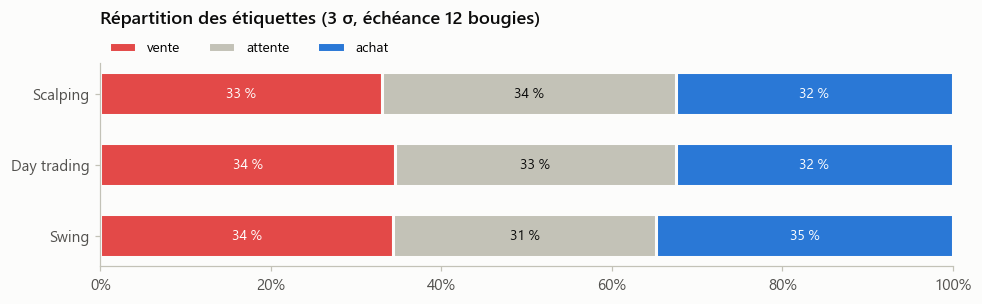

In [8]:
fig, ax = plt.subplots(figsize=(10, 2.4))
profils = list(repartition.index)[::-1]
gauche = np.zeros(len(profils))
for classe, couleur, encre in (("vente", ROUGE, "white"), ("attente", GRIS, ENCRE), ("achat", BLEU, "white")):
    valeurs = repartition.loc[profils, classe].to_numpy(dtype=float)
    ax.barh([NOMS[p] for p in profils], valeurs, left=gauche, color=couleur,
            edgecolor=FOND, linewidth=2, height=0.6, label=classe)
    for i, v in enumerate(valeurs):
        ax.text(gauche[i] + v / 2, i, f"{v:.0f} %", ha="center", va="center", color=encre, fontsize=9)
    gauche += valeurs
ax.set_xlim(0, 100)
# Titre décalé vers le haut (pad) pour laisser la place à la légende juste au-dessus du graphique
ax.set_title("Répartition des étiquettes (3 σ, échéance 12 bougies)", pad=26)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.grid(False)
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), borderaxespad=0.2, fontsize=9)
plt.show()

Les trois classes sont équilibrées dans les trois profils : aucun rééquilibrage n'est nécessaire, et un modèle qui répond toujours la même chose plafonne autour de 35 %.

## 4. Les variables (feature engineering)

La librairie `ta` peut ajouter tous ses indicateurs d'un coup avec `add_all_ta_features`. On regarde d'abord ce que cela donne.

In [9]:
from ta import add_all_ta_features

base = btc_jour.reset_index(drop=True)
tout_ta = add_all_ta_features(base.copy(), open="open", high="high", low="low",
                              close="close", volume="volume", fillna=False)
ajoutees = [c for c in tout_ta.columns if c not in base.columns]
utilisables = [c for c in ajoutees if tout_ta[c].isna().mean() < 0.3]
correlation = tout_ta[utilisables].dropna().corr().abs().to_numpy()

print(f"Colonnes ajoutées                          : {len(ajoutees)}")
print(f"Colonnes vides à plus de 30 %              : {len(ajoutees) - len(utilisables)}")
print(f"Lignes restantes après un dropna() complet : {len(tout_ta.dropna(subset=ajoutees))} sur {len(base)}")
print(f"Paires de colonnes corrélées à plus de 0,95 : {int((np.triu(correlation, 1) > 0.95).sum())}")

Colonnes ajoutées                          : 86
Colonnes vides à plus de 30 %              : 2
Lignes restantes après un dropna() complet : 0 sur 2184
Paires de colonnes corrélées à plus de 0,95 : 231


Trop de colonnes redondantes, et un `dropna()` naïf vide entièrement le jeu. On construit donc une sélection de **variables sans échelle** : uniquement des rapports et des pourcentages, jamais un prix brut. Un modèle qui apprendrait « le BTC vaut 63 000 $ » serait inutilisable sur l'ETH, et sur le BTC l'année suivante.

In [10]:
from src.features import FAMILLES, construire, construire_groupes, colonnes_explicatives

exemple = donnees["swing"].query("symbol == 'BTCUSDT' and interval == '4h'")
familles = {f: list(construire(exemple, (f,)).columns) for f in FAMILLES}
pd.DataFrame([{"famille": f, "nombre": len(v), "variables": ", ".join(v)} for f, v in familles.items()])

,famille,nombre,variables
0,tendance,6,"ecart_sma_10, ecart_sma_30, ecart_sma_100, eca..."
1,momentum,6,"rsi_14, stoch_k, roc_10, rendement_1, rendemen..."
2,volatilite,6,"atr_relatif, position_bollinger, largeur_bolli..."
3,volume,4,"volume_relatif, obv_normalise, mfi, trades_rel..."
4,flux,4,"part_acheteuse, part_acheteuse_moy_12, flux_vs..."


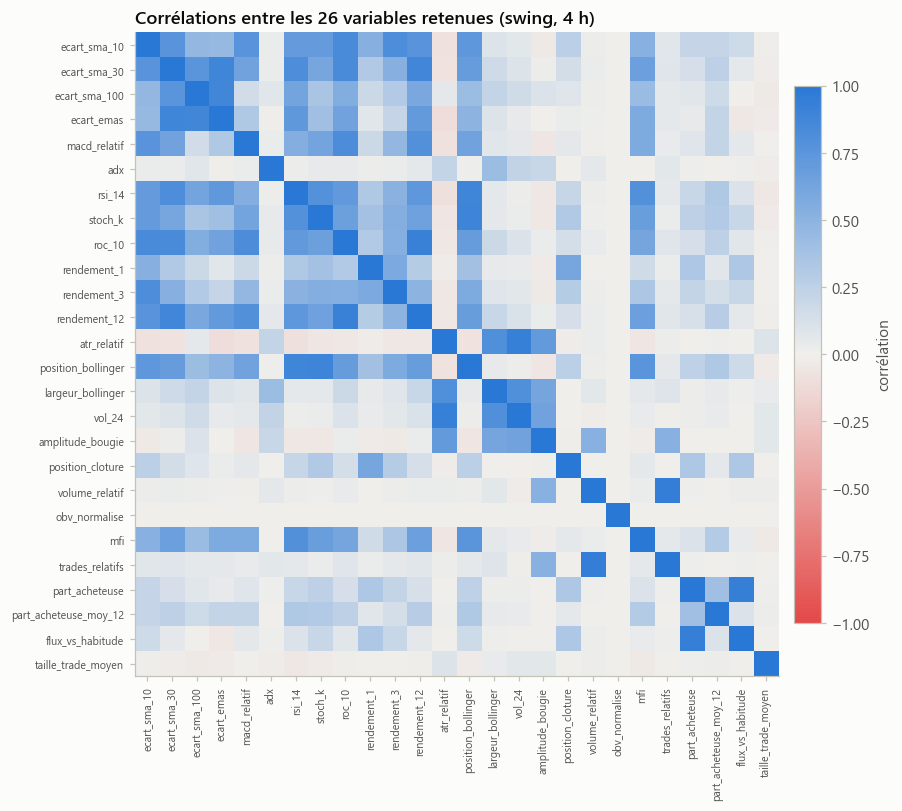

Corrélation la plus forte entre deux variables : 0.939


In [11]:
variables_4h = construire_groupes(donnees["swing"].query("interval == '4h'"))
colonnes = colonnes_explicatives(variables_4h)
matrice = variables_4h[colonnes].corr()

divergente = LinearSegmentedColormap.from_list("vente_neutre_achat", [ROUGE, "#f0efec", BLEU])
fig, ax = plt.subplots(figsize=(9, 7.6))
image = ax.imshow(matrice, cmap=divergente, vmin=-1, vmax=1)
ax.set_xticks(range(len(colonnes)), colonnes, rotation=90, fontsize=7)
ax.set_yticks(range(len(colonnes)), colonnes, fontsize=7)
ax.grid(False)
ax.set_title(f"Corrélations entre les {len(colonnes)} variables retenues (swing, 4 h)")
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="corrélation")
plt.show()

hors_diagonale = np.abs(matrice.to_numpy()[np.triu_indices(len(colonnes), 1)])
print(f"Corrélation la plus forte entre deux variables : {hors_diagonale.max():.3f}")

## 5. Comparaison des modèles

Pour chaque profil, six modèles choisis avec la carte de scikit-learn, dont **deux références** : répondre toujours la classe la plus fréquente, et répondre au hasard. Sans elles, un score ne veut rien dire.

Le découpage est **chronologique** : on entraîne sur les 80 % les plus anciens et on teste sur les 20 % les plus récents. Un découpage aléatoire reviendrait à entraîner sur le futur pour prédire le passé.

In [12]:
from scripts.compare_models import preparer, modeles
from src.scoring import bon_sens_directionnel, SCORER_DIRECTIONNEL, resume

jeux, lignes = {}, []
for profil in config.TRADING_PROFILES:
    X, y = preparer(profil, FAMILLES)
    jeux[profil] = (X, y)
    coupure = int(len(X) * 0.8)
    for nom, modele in modeles(coupure).items():
        prediction = pipeline_de(modele).fit(X.iloc[:coupure], y.iloc[:coupure]).predict(X.iloc[coupure:])
        lignes.append({"profil": profil, "modèle": nom,
                       "accuracy": accuracy_score(y.iloc[coupure:], prediction),
                       "f1 macro": f1_score(y.iloc[coupure:], prediction, average="macro"),
                       "bon sens directionnel": bon_sens_directionnel(y.iloc[coupure:], prediction)})

comparaison = pd.DataFrame(lignes)
comparaison.pivot(index="modèle", columns="profil", values="accuracy")[list(config.TRADING_PROFILES)].round(4)

profil,scalping,day_trading,swing
modèle,,,
foret_aleatoire,0.3848,0.4174,0.3972
gradient_boosting,0.4013,0.4233,0.3950
reference_aleatoire,0.3376,0.3354,0.3355
reference_majoritaire,0.3240,0.3171,0.3475
regression_logistique,0.4149,0.4149,0.3901
sgd_lineaire,0.4016,0.4102,NaN
svm_lineaire,NaN,NaN,0.3903


In [13]:
references = comparaison[comparaison["modèle"].str.startswith("reference")].groupby("profil")["accuracy"].max()
meilleurs = comparaison[~comparaison["modèle"].str.startswith("reference")].sort_values("accuracy").groupby("profil").tail(1)
meilleurs = meilleurs.assign(référence=meilleurs["profil"].map(references))
meilleurs["gain sur la référence"] = meilleurs["accuracy"] - meilleurs["référence"]
meilleurs.set_index("profil").loc[list(config.TRADING_PROFILES)].round(4)

,modèle,accuracy,f1 macro,bon sens directionnel,référence,gain sur la référence
profil,,,,,,
scalping,regression_logistique,0.4149,0.3944,0.5225,0.3376,0.0772
day_trading,gradient_boosting,0.4233,0.4263,0.5063,0.3354,0.0879
swing,foret_aleatoire,0.3972,0.3985,0.5053,0.3475,0.0497


Aucun modèle ne gagne sur les trois profils, ce qui justifie d'en tester plusieurs. Tous battent les références d'environ 5 à 9 points d'accuracy. Mais la dernière colonne, le **bon sens directionnel**, reste proche de 0,5 : la section suivante explique pourquoi c'est elle qui compte.

## 6. Métriques : ce que mesure vraiment chaque chiffre

### Accuracy contre bon sens directionnel

L'accuracy compte toutes les bougies, y compris celles où le modèle dit « attendre » à raison. Le **bon sens directionnel** ne regarde que les cas où le modèle passe un ordre **et** où le marché bouge vraiment : a-t-il misé du bon côté ? Exemple sur le day trading, avec le modèle retenu.

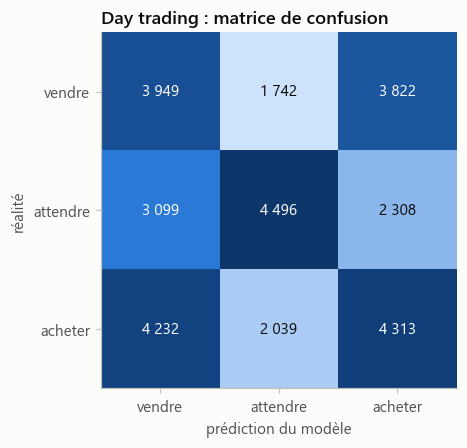

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier

X, y = jeux["day_trading"]
coupure = int(len(X) * 0.8)
modele_dt = pipeline_de(HistGradientBoostingClassifier(
    random_state=0, max_iter=100, max_leaf_nodes=31, learning_rate=0.1))
prediction = modele_dt.fit(X.iloc[:coupure], y.iloc[:coupure]).predict(X.iloc[coupure:])
vrai = y.iloc[coupure:].to_numpy()

matrice = confusion_matrix(vrai, prediction, labels=[-1, 0, 1])
noms = ["vendre", "attendre", "acheter"]
sequentielle = LinearSegmentedColormap.from_list("bleu", ["#cde2fb", "#2a78d6", "#0d366b"])

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.imshow(matrice, cmap=sequentielle)
for i in range(3):
    for j in range(3):
        fonce = matrice[i, j] > matrice.max() * 0.55
        ax.text(j, i, milliers(matrice[i, j]), ha="center", va="center",
                color="white" if fonce else ENCRE, fontsize=10)
ax.set_xticks(range(3), noms)
ax.set_yticks(range(3), noms)
ax.set_xlabel("prédiction du modèle")
ax.set_ylabel("réalité")
ax.grid(False)
ax.set_title("Day trading : matrice de confusion")
plt.show()

In [15]:
agit, bouge = prediction != 0, vrai != 0
concernes = agit & bouge
pd.DataFrame([
    {"mesure": "accuracy", "bonnes réponses": int((prediction == vrai).sum()),
     "sur": len(vrai), "résultat": (prediction == vrai).mean(), "hasard": 1 / 3},
    {"mesure": "bon sens directionnel", "bonnes réponses": int((prediction[concernes] == vrai[concernes]).sum()),
     "sur": int(concernes.sum()), "résultat": (prediction[concernes] == vrai[concernes]).mean(), "hasard": 0.5},
]).round(4)

,mesure,bonnes réponses,sur,résultat,hasard
0,accuracy,12758,30000,0.4253,0.3333
1,bon sens directionnel,8262,16316,0.5064,0.5000


Mêmes prédictions, conclusion opposée : l'accuracy semble bonne (0,43 contre 0,33), mais le bon sens directionnel est au niveau du pile ou face. Le modèle sait repérer les phases calmes, pas la direction du prix. C'est donc le bon sens directionnel que l'on optimise.

### R², RMSE et MAE : le piège de la prédiction du prix

On entraîne des modèles de régression pour prédire soit le **prix** de la bougie suivante, soit son **rendement**, et on les compare à un modèle naïf qui ne calcule rien (« le prochain prix sera le prix actuel », ou « le rendement sera nul »).

In [16]:
from scripts.regression_baseline import preparer as preparer_regression
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

lignes = []
for cible in ("prix", "rendement"):
    X_r, y_r, naif = preparer_regression("scalping", cible)
    c = int(len(X_r) * 0.8)
    for nom, modele in (("modèle naïf", None), ("ridge", Ridge(alpha=1.0)),
                        ("gradient boosting", HistGradientBoostingRegressor(random_state=0))):
        pred = (naif.iloc[c:] if modele is None
                else pipeline_de(modele).fit(X_r.iloc[:c], y_r.iloc[:c]).predict(X_r.iloc[c:]))
        lignes.append({"cible": cible, "modèle": nom,
                       "R²": r2_score(y_r.iloc[c:], pred),
                       "RMSE": np.sqrt(mean_squared_error(y_r.iloc[c:], pred)),
                       "MAE": mean_absolute_error(y_r.iloc[c:], pred)})
regression = pd.DataFrame(lignes)
regression.style.format({"R²": "{:.6f}", "RMSE": "{:.6g}", "MAE": "{:.6g}"}).hide(axis="index")

cible,modèle,R²,RMSE,MAE
prix,modèle naïf,0.999998,42.0335,11.195
prix,ridge,-0.172939,32890,22700.3
prix,gradient boosting,0.974495,4850,2347.31
rendement,modèle naïf,-0.000329,0.00241999,0.00119569
rendement,ridge,-0.021623,0.00244561,0.00120305
rendement,gradient boosting,-0.012248,0.00243436,0.00119971


Sur le prix, le modèle naïf obtient un R² de presque 1 alors qu'il recopie son entrée, et les vrais modèles font moins bien que lui : le R² mesure seulement que le prix bouge peu d'une bougie à l'autre par rapport à son amplitude sur six ans. Sur le rendement, qui est ce qui fait gagner de l'argent, tous les R² sont nuls ou négatifs.

## 7. Optimisation avec GridSearchCV

Deux choix importants :

- le critère optimisé est le **bon sens directionnel**, pas l'accuracy ;
- la validation croisée utilise **`TimeSeriesSplit`** : chaque pli valide sur une période postérieure à son entraînement. Le découpage par défaut mélangerait passé et futur.

Les grilles restent petites : chaque combinaison est entraînée cinq fois.

In [17]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from scripts.optimize_model import GAGNANTS

lignes, grilles = [], {}
for profil, (modele, grille) in GAGNANTS.items():
    X, y = jeux[profil]
    c = int(len(X) * 0.8)
    recherche = GridSearchCV(pipeline_de(modele), grille, scoring=SCORER_DIRECTIONNEL,
                             cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
    recherche.fit(X.iloc[:c], y.iloc[:c])
    mesures = resume(y.iloc[c:], recherche.best_estimator_.predict(X.iloc[c:]))
    n = mesures["ordres_evalues"]
    p_value = stats.binomtest(round(mesures["bon_sens"] * n), n, 0.5, alternative="greater").pvalue
    scores = recherche.cv_results_["mean_test_score"]
    grilles[profil] = pd.DataFrame(recherche.cv_results_["params"]).assign(bon_sens_validation=scores)
    lignes.append({"profil": profil,
                   "meilleurs paramètres": {k.replace("modele__", ""): v for k, v in recherche.best_params_.items()},
                   "combinaisons": len(scores),
                   "bon sens validation": recherche.best_score_,
                   "bon sens test": mesures["bon_sens"],
                   "p-value (test)": p_value,
                   "écart entre combinaisons": scores.max() - scores.min()})
pd.DataFrame(lignes).set_index("profil").round(4)

,meilleurs paramètres,combinaisons,bon sens validation,bon sens test,p-value (test),écart entre combinaisons
profil,,,,,,
scalping,"{'C': 1.0, 'class_weight': None}",6,0.4970,0.5225,0.0000,0.0017
day_trading,"{'learning_rate': 0.1, 'max_iter': 100, 'max_l...",8,0.5079,0.5064,0.0526,0.0028
swing,"{'min_samples_leaf': 20, 'n_estimators': 100}",6,0.5245,0.5121,0.0129,0.0047


In [18]:
grilles["swing"].rename(columns=lambda c: c.replace("modele__", "")).sort_values(
    "bon_sens_validation", ascending=False).round(4)

,min_samples_leaf,n_estimators,bon_sens_validation
0,20,100,0.5245
1,20,200,0.5243
2,50,100,0.5227
4,100,100,0.5204
3,50,200,0.5198
5,100,200,0.5197


Les combinaisons de paramètres ne diffèrent que de quelques millièmes : **les réglages ne changent presque rien, la limite vient du signal**. Le scalping passe sous le hasard en validation mais au-dessus en test, une incohérence qui invite à la prudence ; le day trading n'est pas distinguable du hasard (p-value supérieure à 0,05).

## 8. Modèles finaux et backtest

Un modèle retenu par profil, avec les paramètres issus de l'optimisation. Le swing est entraîné avec des barrières plus larges (5 σ, échéance 48 bougies), le réglage qui l'approche le plus du seuil de rentabilité.

Le **backtest** rejoue les décisions sur la période de test : 10 000 € au départ, 10 % du capital engagé par opération, positions qui ne se chevauchent pas, et **0,1 % de frais** à l'achat comme à la vente. On le compare à un **modèle parfait** qui connaîtrait l'avenir.

In [19]:
from scripts.train_final import preparer as preparer_final, CONFIGURATIONS
from src.backtest import simuler, simuler_parfait

SORTIES = ("rendement_a_la_sortie", "bougies_avant_sortie")
finaux, lignes = {}, []
for profil, cfg in CONFIGURATIONS.items():
    jeu = preparer_final(profil, cfg["largeur"], cfg["horizon"])
    colonnes = [c for c in colonnes_explicatives(jeu) if c not in SORTIES]
    X, y = jeu[colonnes], jeu["label"].astype(int)
    c = int(len(X) * 0.8)
    pipeline = pipeline_de(clone(cfg["modele"])).fit(X.iloc[:c], y.iloc[:c])
    prediction = pipeline.predict(X.iloc[c:])
    test = jeu.iloc[c:].reset_index(drop=True)

    backtest = simuler(prediction, test["rendement_a_la_sortie"], test["bougies_avant_sortie"],
                       fraction_engagee=0.10, retourner_courbe=True)
    parfait = simuler_parfait(test["rendement_a_la_sortie"], test["bougies_avant_sortie"],
                              test["label"], fraction_engagee=0.10)
    mesures = resume(y.iloc[c:], prediction)
    finaux[profil] = {"pipeline": pipeline, "colonnes": colonnes, "cfg": cfg,
                      "mesures": mesures, "backtest": backtest, "X_test": X.iloc[c:]}
    lignes.append({"profil": profil, "modèle": type(cfg["modele"]).__name__,
                   "barrières": f"{cfg['largeur']:g} σ / {cfg['horizon']} bougies",
                   "bon sens": mesures["bon_sens"],
                   "opérations": backtest["operations"],
                   "gain net / opération (%)": backtest["gain_moyen_net_pct"],
                   "capital final (€)": round(backtest["capital_final"]),
                   "performance (%)": backtest["performance_pct"],
                   "modèle parfait, gain / opération (%)": parfait["gain_moyen_net_pct"]})
pd.DataFrame(lignes).set_index("profil").round(4)

,modèle,barrières,bon sens,opérations,gain net / opération (%),capital final (€),performance (%),"modèle parfait, gain / opération (%)"
profil,,,,,,,,
scalping,LogisticRegression,3 σ / 12 bougies,0.5225,3811,-0.1813,5007,-49.93,0.2497
day_trading,HistGradientBoostingClassifier,3 σ / 12 bougies,0.5064,4564,-0.2270,3540,-64.60,0.5274
swing,RandomForestClassifier,5 σ / 48 bougies,0.5160,923,-0.1838,8218,-17.82,6.4677


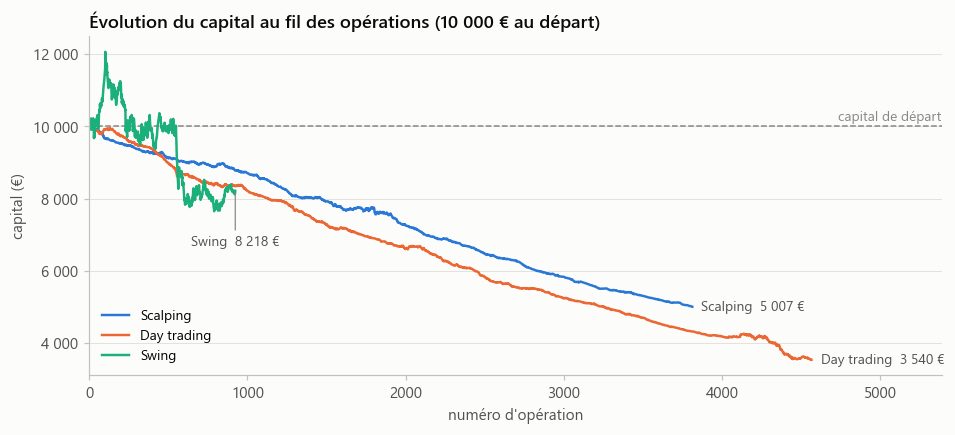

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
x_max = max(len(f["backtest"]["courbe"]) for f in finaux.values()) * 1.18
ax.axhline(10_000, color=DISCRET, linewidth=1, linestyle="--")
# Libellé à droite, là où aucune courbe ne passe
ax.text(x_max, 10_150, "capital de départ", color=DISCRET, fontsize=9, ha="right")
# Le swing s'arrête au milieu des deux autres courbes : son libellé va dessous, dans l'espace libre,
# relié à la fin de sa courbe par un trait fin
placement = {"swing": dict(xytext=(0, -34), ha="center",
                           arrowprops=dict(arrowstyle="-", color=DISCRET, linewidth=0.8))}
for profil, f in finaux.items():
    courbe = f["backtest"]["courbe"]
    ax.plot(range(len(courbe)), courbe, color=COULEURS[profil], label=NOMS[profil])
    ax.annotate(f"{NOMS[profil]}  {milliers(courbe[-1])} €", (len(courbe) - 1, courbe[-1]),
                textcoords="offset points", va="center", color=ENCRE_2, fontsize=9,
                **placement.get(profil, dict(xytext=(6, 0))))
ax.set_title("Évolution du capital au fil des opérations (10 000 € au départ)")
ax.set_xlabel("numéro d'opération")
ax.set_ylabel("capital (€)")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(milliers))
ax.grid(axis="x", visible=False)
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(0, x_max)
plt.show()

**Les trois profils perdent de l'argent, alors qu'un modèle parfait serait rentable partout.** Les barrières contiennent donc du signal exploitable : c'est la prédiction de la direction qui échoue, et les frais de 0,2 % par aller-retour absorbent le peu d'avantage restant.

## 9. Suivi MLflow

Chaque modèle final est enregistré avec ses paramètres, ses métriques, le pipeline complet et l'empreinte de l'extrait figé. Les exécutions de ce notebook sont regroupées dans l'expérience `cryptobot_notebook`, à côté de celles des scripts (`cryptobot_etape3`).

Pour consulter l'interface : `mlflow ui --backend-store-uri sqlite:///mlflow.db`, puis l'onglet **Model training**.

In [21]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{(RACINE / 'mlflow.db').as_posix()}")
if mlflow.get_experiment_by_name("cryptobot_notebook") is None:
    mlflow.create_experiment("cryptobot_notebook",
                             artifact_location=(RACINE / "mlartifacts").as_uri())
mlflow.set_experiment("cryptobot_notebook")

for profil, f in finaux.items():
    with mlflow.start_run(run_name=f"notebook_{profil}"):
        mlflow.log_params({"profil": profil,
                           "modele": type(f["cfg"]["modele"]).__name__,
                           "largeur_barrieres_sigma": f["cfg"]["largeur"],
                           "horizon_bougies": f["cfg"]["horizon"],
                           "variables": len(f["colonnes"]),
                           "extrait_sha256": manifeste["profils"][profil]["sha256"]})
        mlflow.log_metrics({"bon_sens_directionnel": f["mesures"]["bon_sens"],
                            "accuracy_globale": f["mesures"]["accuracy_globale"],
                            "taux_activite": f["mesures"]["taux_activite"],
                            "backtest_performance_pct": f["backtest"]["performance_pct"],
                            "backtest_gain_net_par_operation_pct": f["backtest"]["gain_moyen_net_pct"]})
        mlflow.sklearn.log_model(f["pipeline"], name="pipeline", skops_trusted_types=["numpy.dtype"])

executions = mlflow.search_runs(experiment_names=["cryptobot_notebook"])
executions[["tags.mlflow.runName", "params.modele", "metrics.bon_sens_directionnel",
            "metrics.backtest_performance_pct"]].round(4)

,tags.mlflow.runName,params.modele,metrics.bon_sens_directionnel,metrics.backtest_performance_pct
0,notebook_swing,RandomForestClassifier,0.5160,-17.82
1,notebook_day_trading,HistGradientBoostingClassifier,0.5064,-64.60
2,notebook_scalping,LogisticRegression,0.5225,-49.93
3,notebook_swing,RandomForestClassifier,0.5160,-17.82
4,notebook_day_trading,HistGradientBoostingClassifier,0.5064,-64.60
5,notebook_scalping,LogisticRegression,0.5225,-49.93
6,notebook_swing,RandomForestClassifier,0.5160,-17.82
7,notebook_day_trading,HistGradientBoostingClassifier,0.5064,-64.60
8,notebook_scalping,LogisticRegression,0.5225,-49.93


## 10. Export des modèles

Chaque modèle est exporté en `.joblib` avec tout ce dont l'API de l'étape 4 aura besoin : le pipeline complet, la liste des colonnes attendues, les réglages des barrières et l'empreinte des données. On vérifie ensuite que le fichier rechargé prédit exactement la même chose.

In [22]:
import joblib

lignes = []
for profil, f in finaux.items():
    chemin = RACINE / "models" / f"{profil}.joblib"
    chemin.parent.mkdir(exist_ok=True)
    joblib.dump({"pipeline": f["pipeline"], "colonnes": f["colonnes"], "profil": profil,
                 "largeur_barrieres": f["cfg"]["largeur"], "horizon": f["cfg"]["horizon"],
                 "extrait_sha256": manifeste["profils"][profil]["sha256"],
                 "entraine_le": datetime.now(timezone.utc).isoformat(),
                 "mesures": f["mesures"]}, chemin)
    recharge = joblib.load(chemin)
    echantillon = f["X_test"].iloc[:2000]
    identique = (recharge["pipeline"].predict(echantillon[recharge["colonnes"]])
                 == f["pipeline"].predict(echantillon)).all()
    lignes.append({"fichier": chemin.name, "taille (ko)": round(chemin.stat().st_size / 1024),
                   "colonnes attendues": len(recharge["colonnes"]),
                   "rechargement identique": "oui" if identique else "NON"})
pd.DataFrame(lignes)

,fichier,taille (ko),colonnes attendues,rechargement identique
0,scalping.joblib,4,27,oui
1,day_trading.joblib,1120,27,oui
2,swing.joblib,25833,27,oui


## Conclusion

- La chaîne est complète : extrait figé, étiquetage intégrant stop loss et take profit, variables sans échelle, six modèles comparés à des références, optimisation chronologique, backtest en euros, suivi MLflow et export.
- **La volatilité se prédit, la direction non.** Les modèles battent les références en accuracy parce qu'ils repèrent les phases calmes, mais leur bon sens directionnel reste proche de 50 %.
- **Aucun profil n'est rentable** une fois les frais de 0,2 % par aller-retour déduits, alors qu'un modèle parfait le serait : la limite vient de la prédiction de la direction, pas de la stratégie.

**Pièges évités, et vérifiés par des tests** (`tests/`) : découpage chronologique partout, normalisation dans le pipeline, étiquetage sans regard vers le futur, et rattachement des pas de temps lents sur leur clôture (une erreur à cet endroit donnait 9 points de bon sens entièrement fictifs).